In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.inspection import permutation_importance
 
RandomState = 0
# apply the preprocessing pipeline
preprocessor = joblib.load("../preprocessing/preprocessor.pkl")
X_train, X_test, y_train, y_test = joblib.load("../preprocessing/data_splits.pkl")
X_train_transformed = preprocessor.fit_transform(X_train) 
X_test_transformed = preprocessor.transform(X_test)

# get our feature names, includes a try catch just in case (Sorry Hassan)
try:
    feature_names = preprocessor.get_feature_names_out()
except AttributeError:
    feature_names = np.array([f"Feature {i}" for i in range(X_train_transformed.shape[1])])

--- Random Forest Results ---
Overall Accuracy: 0.8528



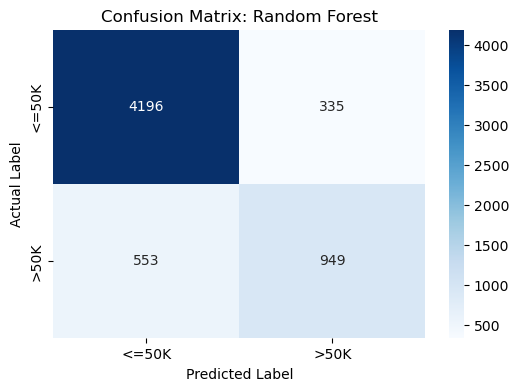

--- Detailed Classification Report ---
              precision  recall  f1-score   support
<=50K             0.884   0.926     0.904  4531.000
>50K              0.739   0.632     0.681  1502.000
accuracy          0.853   0.853     0.853     0.853
macro avg         0.811   0.779     0.793  6033.000
weighted avg      0.848   0.853     0.849  6033.000


In [2]:
# instantiate random forest classifier and make prediction
clf = RandomForestClassifier(criterion="entropy", random_state=RandomState, n_jobs=-1)
clf.fit(X_train_transformed, y_train)

y_pred = clf.predict(X_test_transformed)

# model evaluation
score = clf.score(X_test_transformed, y_test)
cm = confusion_matrix(y_test, y_pred)

# output
print(f"--- Random Forest Results ---")
print(f"Overall Accuracy: {score:.4f}\n")

# confusion Matrix Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['<=50K', '>50K'], 
            yticklabels=['<=50K', '>50K'])
plt.title('Confusion Matrix: Random Forest')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# classification Report
report = classification_report(y_test, y_pred, output_dict=True, target_names=['<=50K', '>50K'])
report_df = pd.DataFrame(report).transpose()

print("--- Detailed Classification Report ---")
print(report_df.round(3).to_string())

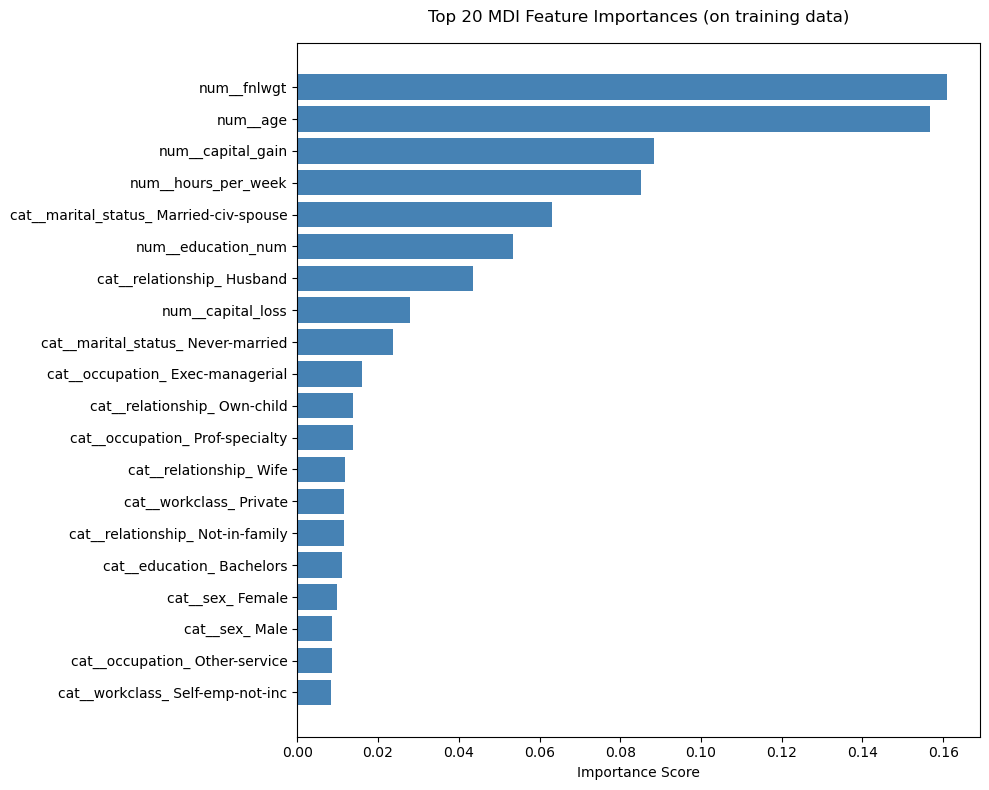

In [3]:
# global Feature Importance (MDI)
fi_mdi = clf.feature_importances_

# select only the top 20 features
sorted_idx_mdi = fi_mdi.argsort()
top_n = 20
top_idx = sorted_idx_mdi[-top_n:] 

# plot our graph
plt.figure(figsize=(10, 8))
plt.barh(feature_names[top_idx], fi_mdi[top_idx], color='steelblue')
plt.title(f"Top {top_n} MDI Feature Importances (on training data)", fontsize=12, pad=15)
plt.xlabel("Importance Score")
plt.tight_layout() 
plt.show()

In [6]:
X_test_dense = X_test_transformed.toarray()

# calculate permutation feature importance over 50 repeats using the dense array
result = permutation_importance(
    clf, X_test_dense, y_test, 
    n_repeats=50, random_state=RandomState, n_jobs=-1
)

C:\Users\thoma\AppData\Local\Temp\ipykernel_5976\744376884.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


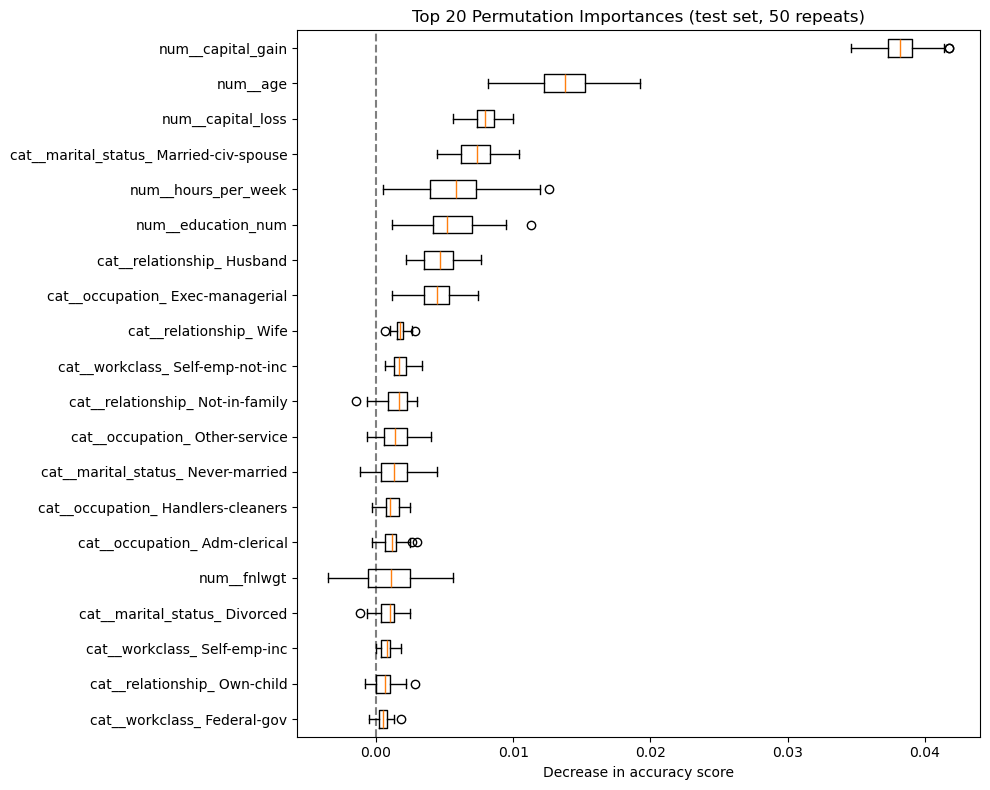

In [7]:
# sort based on the mean importance
sorted_idx_pfi = result.importances_mean.argsort()

# Select only the top 20 features
top_n = 20
top_idx_pfi = sorted_idx_pfi[-top_n:]

# boxplot based on pfi
plt.figure(figsize=(10, 8))
plt.boxplot(
    result.importances[top_idx_pfi].T, 
    vert=False, 
    labels=feature_names[top_idx_pfi]
)
plt.title(f"Top {top_n} Permutation Importances (test set, 50 repeats)")
plt.xlabel("Decrease in accuracy score")
plt.axvline(x=0, color='k', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()